<a href="https://colab.research.google.com/github/eshghinezhad/BackendAPI-RenderDeployment-MediaManagement/blob/main/medical_insurance_charges_prediction_GBR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Predicting medical insurance charges using Gradient Boosting Regressor.


In [ ]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# for data Visualization
%matplotlib inline
import matplotlib.pyplot as plt   # Basic plotting
import seaborn as sns             # Advanced & beautiful statistical plots


# Seaborn & Matplotlib style
sns.set_style("whitegrid")              # clean background
sns.set_palette("Set2")                 # soft color palette
plt.rcParams['figure.figsize'] = (8,5)  # default figure size
plt.rcParams['axes.titlesize'] = 14     # title font size
plt.rcParams['axes.labelsize'] = 12     # axis label font size
plt.rcParams['font.family'] = 'serif'   # font style

import shap
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,GradientBoostingRegressor

import warnings                   # To handle warnings in notebook
warnings.filterwarnings("ignore")


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/medical-insurance-cost-dataset/insurance.csv


### Load the Dataset

In [ ]:
df=pd.read_csv("/kaggle/input/medical-insurance-cost-dataset/insurance.csv")
print("First 5 Rows Data")
df.head()

First 5 Rows Data


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
print(f"In Given Dataset , Rows are: {df.shape[0]} and Columns are: {df.shape[1]}")

In Given Dataset , Rows are: 1338 and Columns are: 7


In [ ]:
print("Overview of the Data")
df.info()

Overview of the Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Dataset Overview

The dataset consists of multiple attributes related to individual health and insurance charges. Below is a summary of key numerical features:

| Feature   | Description                         | Range          |
|-----------|-------------------------------------|----------------|
| Age       | Age of the individual               | 18 – 64       |
| BMI       | Body Mass Index                      | 15 – 54       |
| Children  | Number of children/dependents       | 0 – 5         |
| Charges   | Insurance charges (in USD)          | 1,121 – 63,770|

*Note:* The ranges indicate the minimum and maximum values observed for each feature.


In [ ]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

There is no missing values are present in the Dataset .

In [ ]:
df.duplicated().sum()

1

In [ ]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

### Exploratory Data Analysis

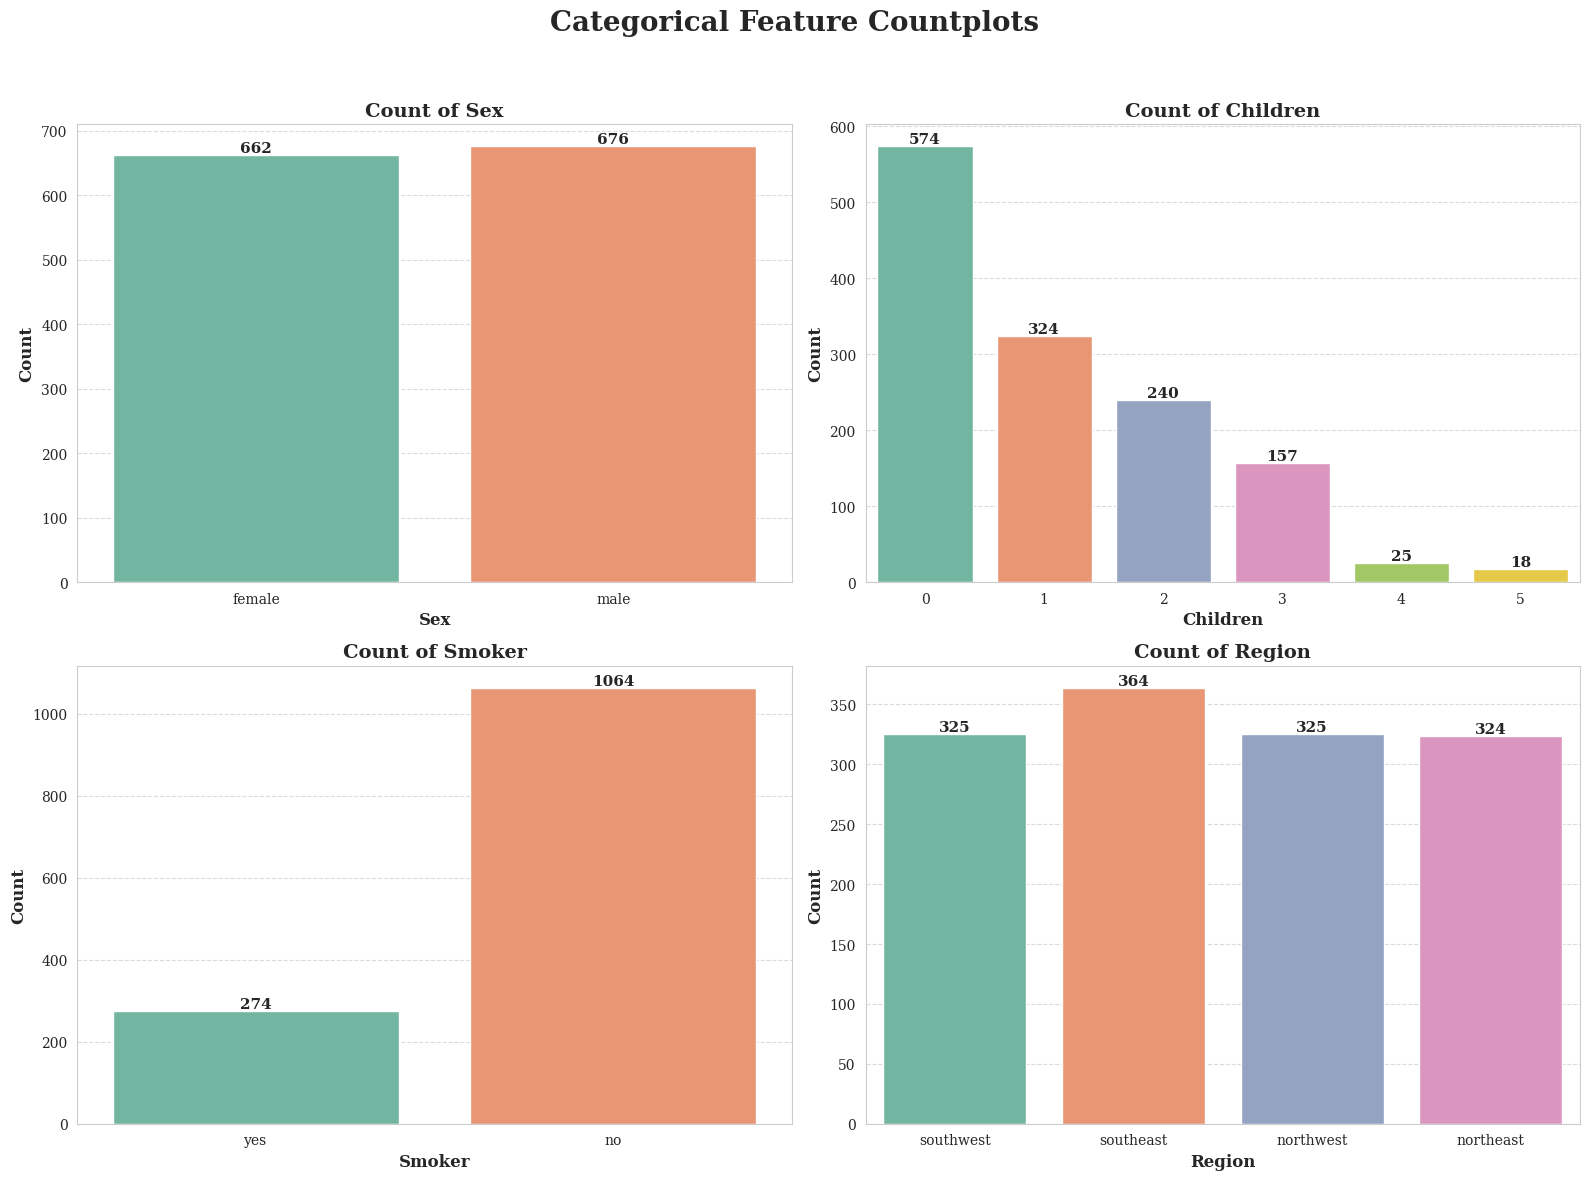

In [ ]:
# Columns to plot
columns = ['sex', 'children', 'smoker', 'region']

# Create subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(16,12))
fig.suptitle("Categorical Feature Countplots", fontsize=20, fontweight='bold')

for ax, col in zip(axes.flatten(), columns):
    sns.countplot(data=df, x=col, ax=ax, palette="Set2")
    ax.set_xlabel(col.capitalize(), fontsize=12, fontweight='bold')
    ax.set_ylabel("Count", fontsize=12, fontweight='bold')
    ax.set_title(f"Count of {col.capitalize()}", fontsize=14, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Annotate counts on bars
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width()/2., height),
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Rotate x-axis labels if needed
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to include suptitle
plt.show()


# Categorical Feature Analysis

This section explores the **key categorical variables** in the dataset: `sex`, `children`, `smoker`, and `region`. The analysis includes **countplots** and **insights** for each feature.

---

## **1. Sex Distribution**
- **Males:** 676  
- **Females:** 662  

**Observation:**  
Males slightly outnumber females, but the difference is small (~2%).

---

## **2. Children Distribution**

| Number of Children | Count |
|-------------------|-------|
| 0                 | 676   |
| 1                 | 324   |
| 2                 | 240   |
| 3                 | 157   |
| 4                 | 25    |
| 5                 | 18    |

**Observation:**  
- Most individuals have **0 children** (~40%).  
- Having **1–2 children** is common, while **3 or more children** are increasingly rare.

---

## **3. Smoker Status**
- **Smokers:** 274  
- **Non-Smokers:** 1064  

**Observation:**  
Majority of the population are **non-smokers (~80%)**, while smokers are a smaller minority (~20%).

---

## **4. Region Distribution**
- **South-West:** 325  
- **South-East:** 364  
- **North-West:** 325  
- **North-East:** 324  

**Observation:**  
The dataset is **well balanced across regions**, with South-East slightly higher than others.

---

### **Conclusion**
- Dataset is **well balanced** in terms of sex and region.  
- Most individuals are **non-smokers** and **childless**.  
- The children distribution reflects **realistic demographic patterns**.  

>  These insights can guide **feature engineering** and **modeling strategies** in predictive analysis, forecasting, or classification tasks.


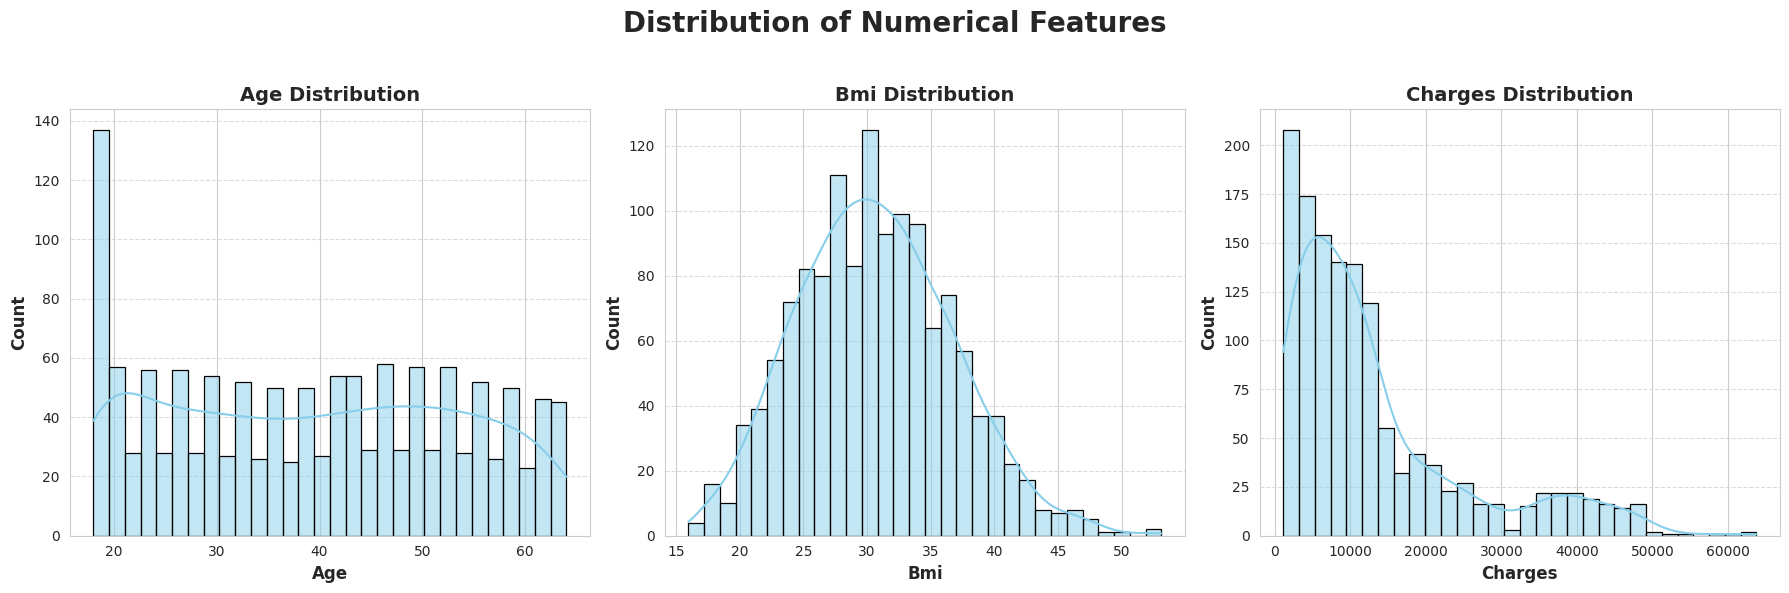

In [ ]:
# Numerical columns
num_cols = ['age', 'bmi', 'charges']

# Set style
sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (16,12)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18,6))
fig.suptitle("Distribution of Numerical Features", fontsize=20, fontweight='bold')

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, bins=30, color='skyblue', edgecolor='black')
    ax.set_title(f"{col.capitalize()} Distribution", fontsize=14, fontweight='bold')
    ax.set_xlabel(col.capitalize(), fontsize=12, fontweight='bold')
    ax.set_ylabel("Count", fontsize=12, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Numerical Feature Analysis

This section explores the **distribution of numerical variables**: `age`, `bmi`, and `charges`. Histograms combined with KDE plots are used for visualization.

---

## **1. Age Distribution**
- Observations:  
  - Age is **uniformly distributed** across most of the population.  
  - However, there is a **noticeable peak at 18 years**, indicating a higher number of young adults in the dataset.

---

## **2. BMI (Body Mass Index) Distribution**
- Observations:  
  - BMI appears to follow a **normal distribution**.  
  - Most individuals have BMI around the **central range**, with fewer people at the extremes.

---

## **3. Charges Distribution**
- Observations:  
  - Charges are **right-skewed**, meaning most individuals have lower medical charges, but a few have very high charges.  
  - This skewness should be considered for **modeling and transformations** in regression tasks.

---

### **Conclusion**
- **Age:** Mostly uniform, slight peak at 18.  
- **BMI:** is normal distribution.  
- **Charges:** Right-skewed distribution, presence of outliers with very high values.  

>  These insights are essential for **feature engineering, scaling, and choosing appropriate models** for predictive analysis.


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


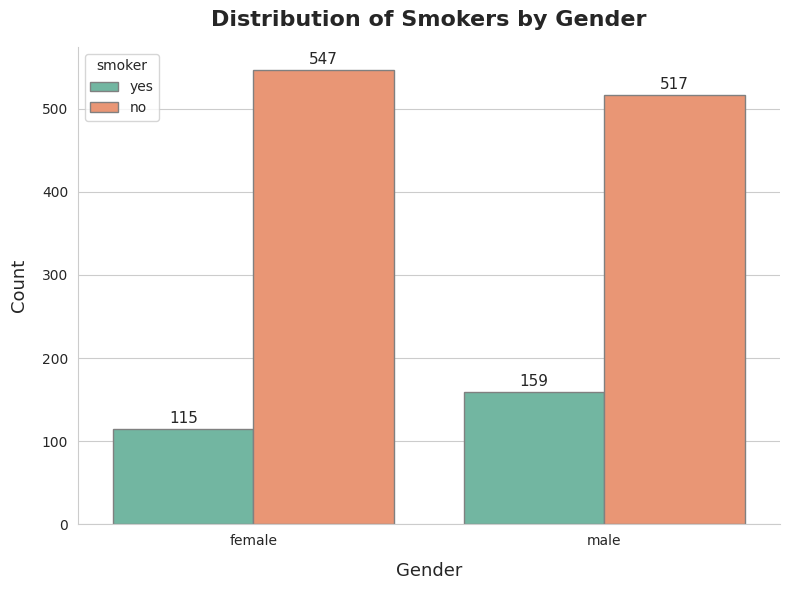

In [ ]:
# Create the figure
plt.figure(figsize=(8, 6))

# Plot
sns.countplot(
    data=df,
    x='sex',
    hue='smoker',
    palette='Set2',
    edgecolor='gray'
)

# Add titles and labels
plt.title('Distribution of Smokers by Gender', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Gender', fontsize=13, labelpad=10)
plt.ylabel('Count', fontsize=13, labelpad=10)

# Add value annotations on bars
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d', label_type='edge', fontsize=11, padding=2)

# Clean up chart
sns.despine()
plt.tight_layout()
plt.show()

# Insights on Smoking and Insurance Charges

The majority of both males and females in the dataset are non-smokers.
However, there are 159 male smokers and 115 female smokers.

Smokers generally face higher insurance charges due to the increased risk of serious health issues such as heart disease, lung problems, and cancer.
Insurance companies, therefore, classify smokers as high-risk individuals, leading to higher premium amounts compared to non-smokers.

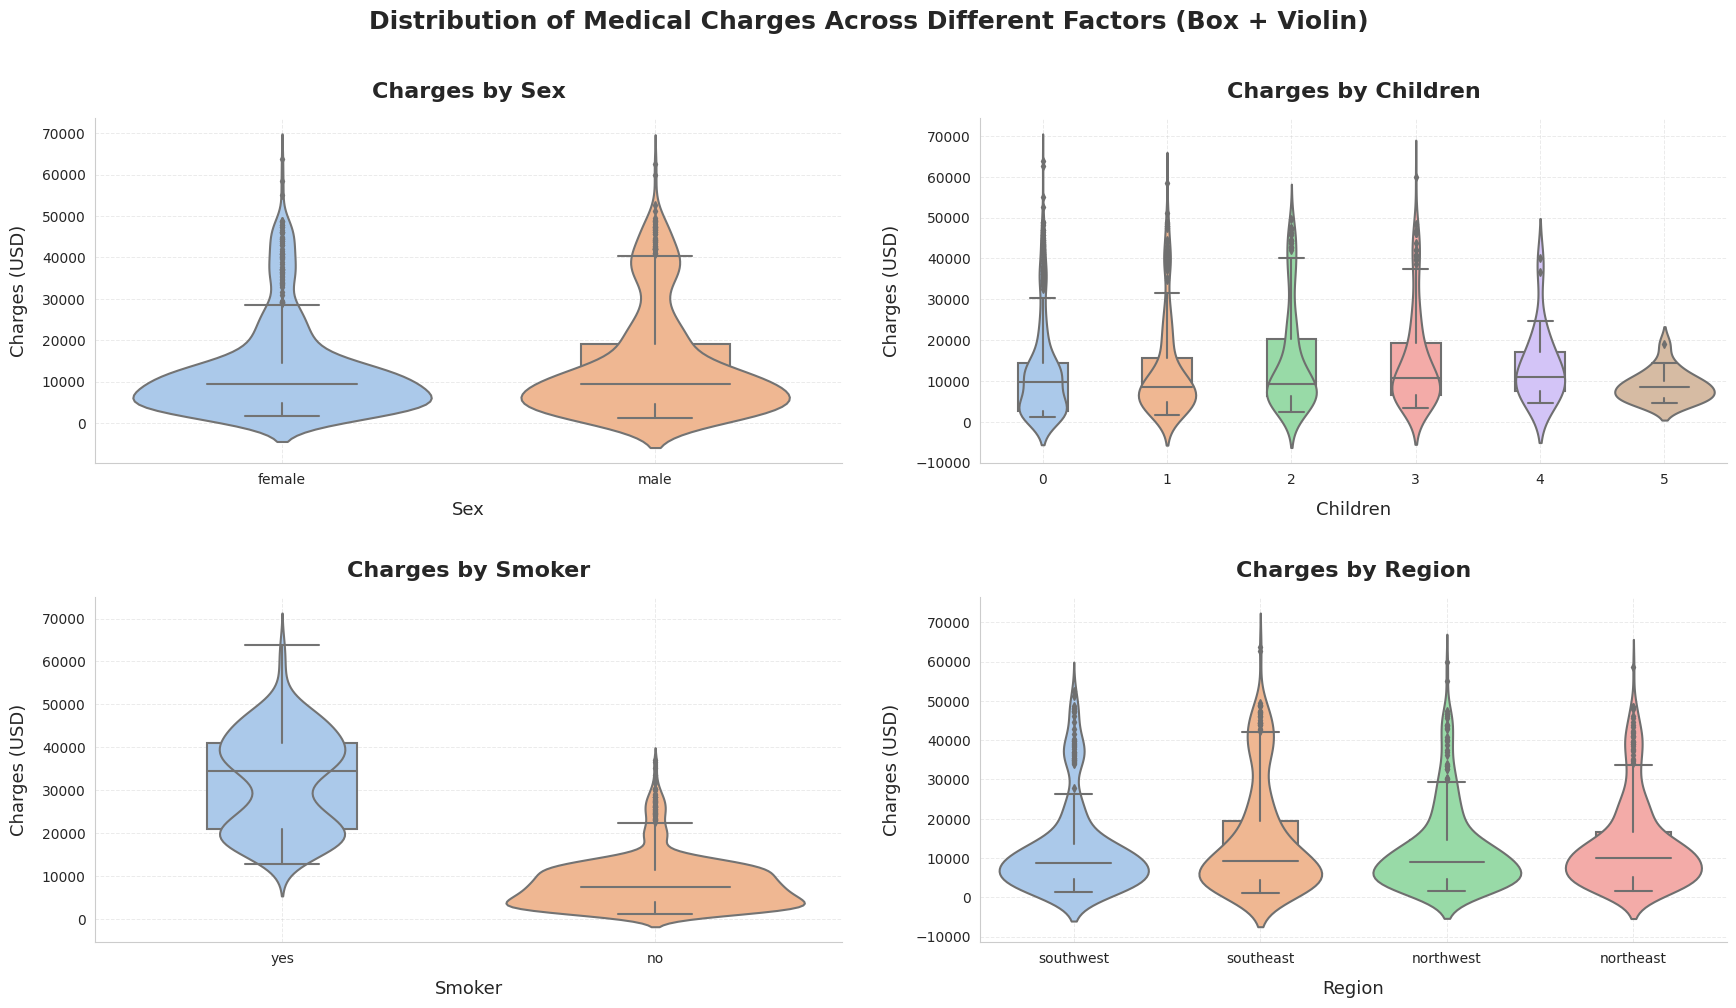

In [ ]:
# Columns to plot
columns = ['sex', 'children', 'smoker', 'region']

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

# Professional color palette
palette = sns.color_palette("pastel")

# Plot boxplots + violin plots side by side
for ax, col in zip(axes, columns):
    # Violin plot (light alpha)
    sns.violinplot(
        data=df,
        x=col,
        y='charges',
        ax=ax,
        palette=palette,
        inner=None,   # Remove inner markings
        alpha=0.3
    )

    # Boxplot on top
    sns.boxplot(
        data=df,
        x=col,
        y='charges',
        ax=ax,
        width=0.4,
        fliersize=4,
        palette=palette
    )

    # Titles and labels
    ax.set_title(f'Charges by {col.capitalize()}', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel(col.capitalize(), fontsize=13, labelpad=10)
    ax.set_ylabel('Charges (USD)', fontsize=13, labelpad=10)

    # Grid and clean look
    ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.4)
    sns.despine(ax=ax, left=False, bottom=False)

# Adjust layout for balance
plt.tight_layout(pad=3)

# Add main title
fig.suptitle('Distribution of Medical Charges Across Different Factors (Box + Violin)',
             fontsize=18, fontweight='bold', y=1.03)

plt.show()

# Analysis of Medical Charges by Different Factors

1. Charges by Sex:
The median insurance charges for both males and females are almost the same.
However, the distribution among males is much wider and more varied compared to females, indicating higher variability in medical expenses for men.

2. Charges by Smoking Status:
Smokers have significantly higher insurance charges and a greater median than non-smokers.
This is because smoking increases the risk of severe health issues, making smokers high-risk individuals for insurance companies.

3. Charges by Number of Children:
Individuals with five children tend to pay the lowest insurance charges, while those with two or three children have the highest charges.
People with no children generally pay less than those with 2–3 children, but more than those with five.

4. Charges by Region:
The median insurance charges are almost similar across all four regions.
However, the Southeast region shows the widest distribution, meaning the variation in charges is highest there.
The Northeast region also has slightly higher charges, whereas Northwest and Southwest regions show comparatively lower charges.

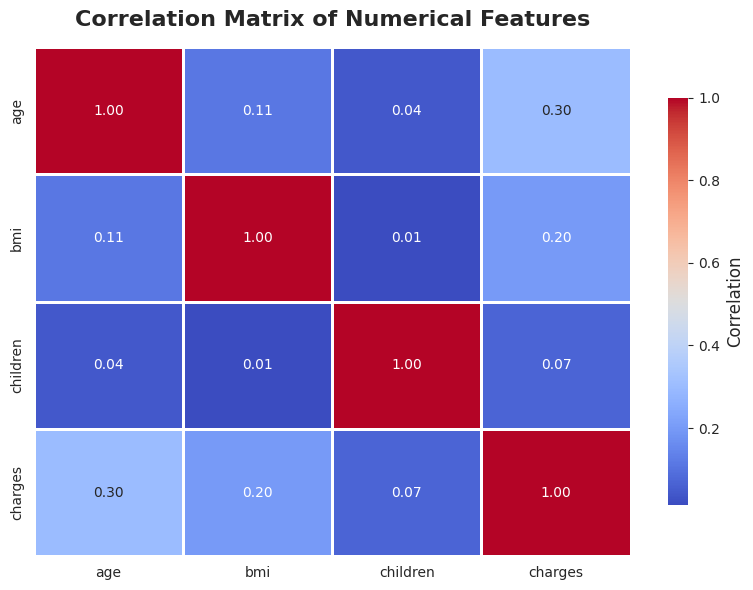

In [ ]:
# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Create figure
plt.figure(figsize=(8, 6))

# Plot heatmap
sns.heatmap(
    corr_matrix,
    annot=True,               # Show correlation values
    fmt=".2f",                # 2 decimal places
    cmap="coolwarm",          # Professional diverging palette
    linewidths=0.8,           # Lines between cells
    linecolor='white',        # Cell borders
    cbar_kws={"shrink": 0.8, "label": "Correlation"}  # Colorbar
)

# Title
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# Correlation of Charges with Other Features

Medical charges (target variable) show a strong positive correlation with BMI and age, indicating that:

As BMI increases, insurance charges tend to increase.

As age increases, insurance charges also tend to increase.

Number of children has a very weak correlation (~0.07) with charges, suggesting that the number of children has minimal impact on the insurance cost.

### Data Cleaning and Preprocessing

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
X=df.drop('charges',axis=1)
y=df['charges']

In [ ]:
# Define feature groups
numeric_features = ['age', 'bmi']
categorical_features = ['sex', 'smoker', 'region']
ordinal_features = ['children']  # Already numeric, keep as is

# Create column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
        ('ord', 'passthrough', ordinal_features)  # keep 'children' as is
    ]
)

In [ ]:
X_transformed=preprocessor.fit_transform(X)

In [ ]:
X_transformed

array([[-1.44041773, -0.45315959,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       [-1.51164747,  0.50942165,  1.        , ...,  1.        ,
         0.        ,  1.        ],
       [-0.79935006,  0.3831546 ,  1.        , ...,  1.        ,
         0.        ,  3.        ],
       ...,
       [-1.51164747,  1.01448983,  0.        , ...,  1.        ,
         0.        ,  0.        ],
       [-1.29795825, -0.79752426,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 1.55123139, -0.26129928,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

In [ ]:
# Get encoded feature names
encoded_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

# Combine all column names
all_features = numeric_features + list(encoded_cols) + ordinal_features

# Create DataFrame
X_transformed_df = pd.DataFrame(X_transformed, columns=all_features)

X_transformed_df.head()


,age,bmi,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,children
0,-1.440418,-0.453160,0.0,1.0,0.0,0.0,1.0,0.0
1,-1.511647,0.509422,1.0,0.0,0.0,1.0,0.0,1.0
2,-0.799350,0.383155,1.0,0.0,0.0,1.0,0.0,3.0
3,-0.443201,-1.305052,1.0,0.0,1.0,0.0,0.0,0.0
4,-0.514431,-0.292456,1.0,0.0,1.0,0.0,0.0,0.0


### Train Test Split

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_transformed_df, y,
    test_size=0.2,       # 20% test data
    random_state=42,     # ensures reproducibility
    stratify=None        # can use if classification problem
)


In [ ]:
print(f"X_train : Rows - {X_train.shape[0]} and Columns - {X_train.shape[1]}")
print(f"X_test : Rows - {X_test.shape[0]} and Columns - {X_test.shape[1]}")

X_train : Rows - 1069 and Columns - 8
X_test : Rows - 268 and Columns - 8


In [ ]:
# Step 2: Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 3: Predict on test data
y_pred = model.predict(X_test)

# Step 4: Evaluate model performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Performance:")
print(f"R² Score: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Model Performance:
R² Score: 0.807
MAE: 4177.05
RMSE: 5956.34


In [ ]:
# 🔧 Define models to compare
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Model": name,
        "R² Score": round(r2, 3),
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2)
    })

# Create a DataFrame for comparison
results_df = pd.DataFrame(results).sort_values(by="R² Score", ascending=False)
print("Model Performance Comparison:\n")
print(results_df)

Model Performance Comparison:

               Model  R² Score      MAE     RMSE
4  Gradient Boosting     0.897  2569.07  4359.67
3      Random Forest     0.881  2628.85  4680.46
0  Linear Regression     0.807  4177.05  5956.34
2   Lasso Regression     0.807  4177.05  5956.36
1   Ridge Regression     0.806  4193.90  5971.88


In [ ]:
# Model
gbr = GradientBoostingRegressor(random_state=42)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}


In [ ]:
grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring='r2',        # maximize R²
    n_jobs=-1,           # use all cores
    verbose=1
)

# Fit on preprocessed training data
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 162 candidates, totalling 810 fits


GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='r2', verbose=1)

In [ ]:
print("Best Hyperparameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 0.8}


In [ ]:
y_pred_best = best_model.predict(X_test)

# Evaluate
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
r2 = r2_score(y_test, y_pred_best)
mae = mean_absolute_error(y_test, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))

print(f"R² Score: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


R² Score: 0.903
MAE: 2494.69
RMSE: 4231.36


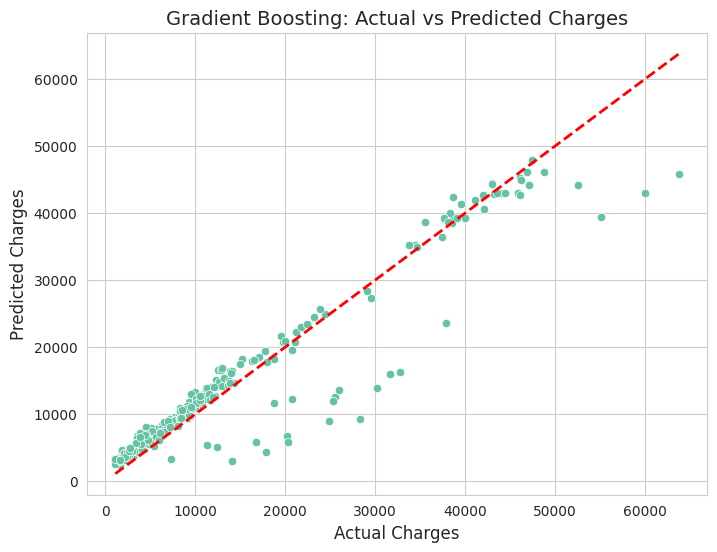

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_best)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Gradient Boosting: Actual vs Predicted Charges")
plt.show()


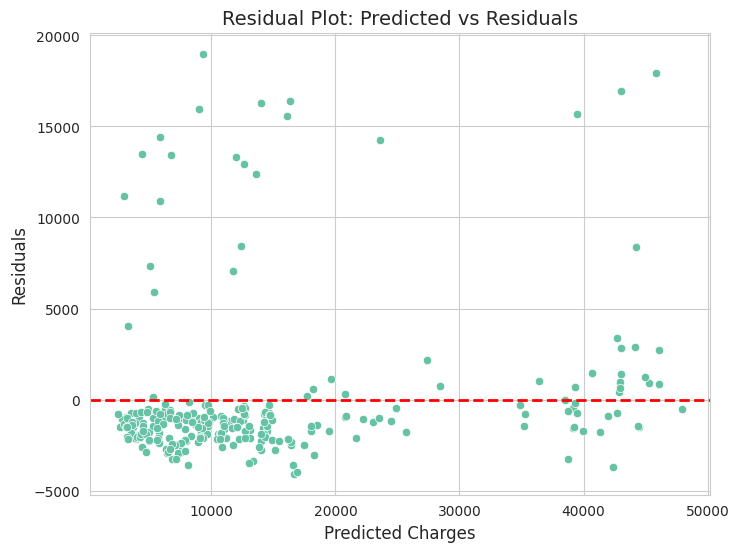

In [ ]:
residuals = y_test - y_pred_best
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred_best, y=residuals)
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot: Predicted vs Residuals")
plt.show()


In [ ]:
features=X_test.columns

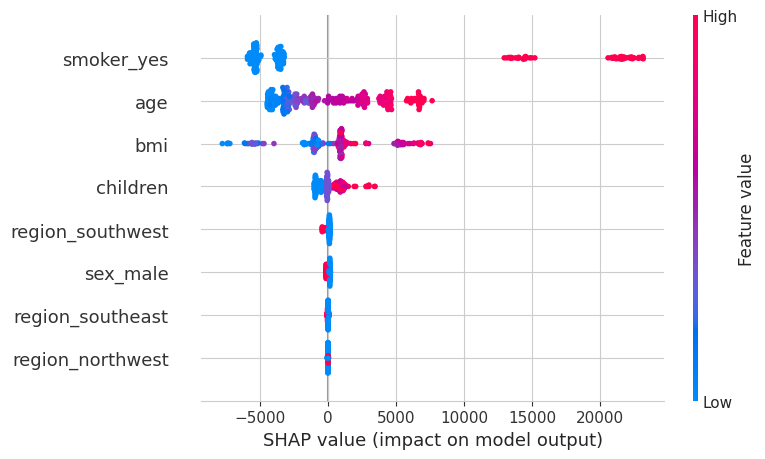

In [ ]:
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, features=X_test, feature_names=features)


### Insights
In the given dataset, the SHAP analysis shows that smoker_yes, age, bmi, and children are the strongest predictors of medical insurance charges.
Smoker status contributes the most to increasing charges, followed by age and BMI, while the number of children has a moderate effect. This confirms that health risk factors drive insurance pricing significantly

In [ ]:
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')
print("CV R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())


CV R² scores: [0.80697977 0.8640603  0.83835629 0.85642    0.85189423]
Mean CV R²: 0.8435421185642256


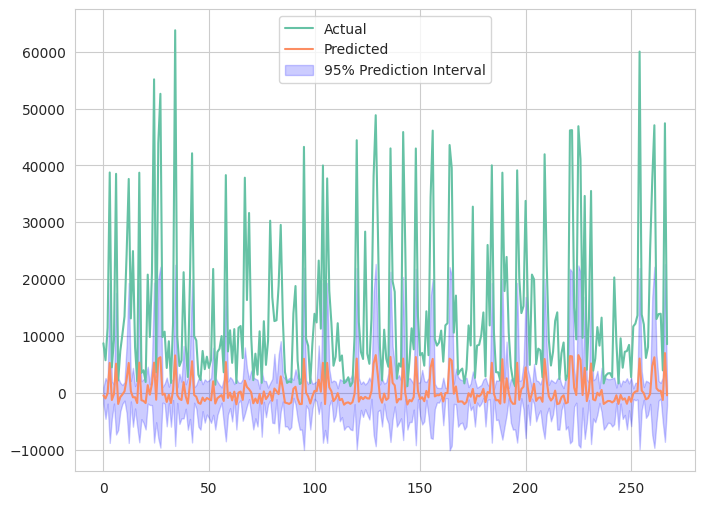

In [ ]:
# Example: Simple approximation using std of predictions from multiple trees (for illustration)
all_tree_preds = np.array([t.predict(X_test) for t in best_model.estimators_.ravel()])
pred_mean = all_tree_preds.mean(axis=0)
pred_std = all_tree_preds.std(axis=0)

lower = pred_mean - 1.96*pred_std
upper = pred_mean + 1.96*pred_std

plt.figure(figsize=(8,6))
plt.plot(y_test.values, label="Actual")
plt.plot(pred_mean, label="Predicted")
plt.fill_between(range(len(y_test)), lower, upper, color='b', alpha=0.2, label="95% Prediction Interval")
plt.legend()
plt.show()


## Partial Dependence Plots (PDP) — Updated for scikit-learn >=1.2

Partial Dependence Plots show the effect of individual features on the target
while averaging out the effects of other features.


In [ ]:
features=X.columns

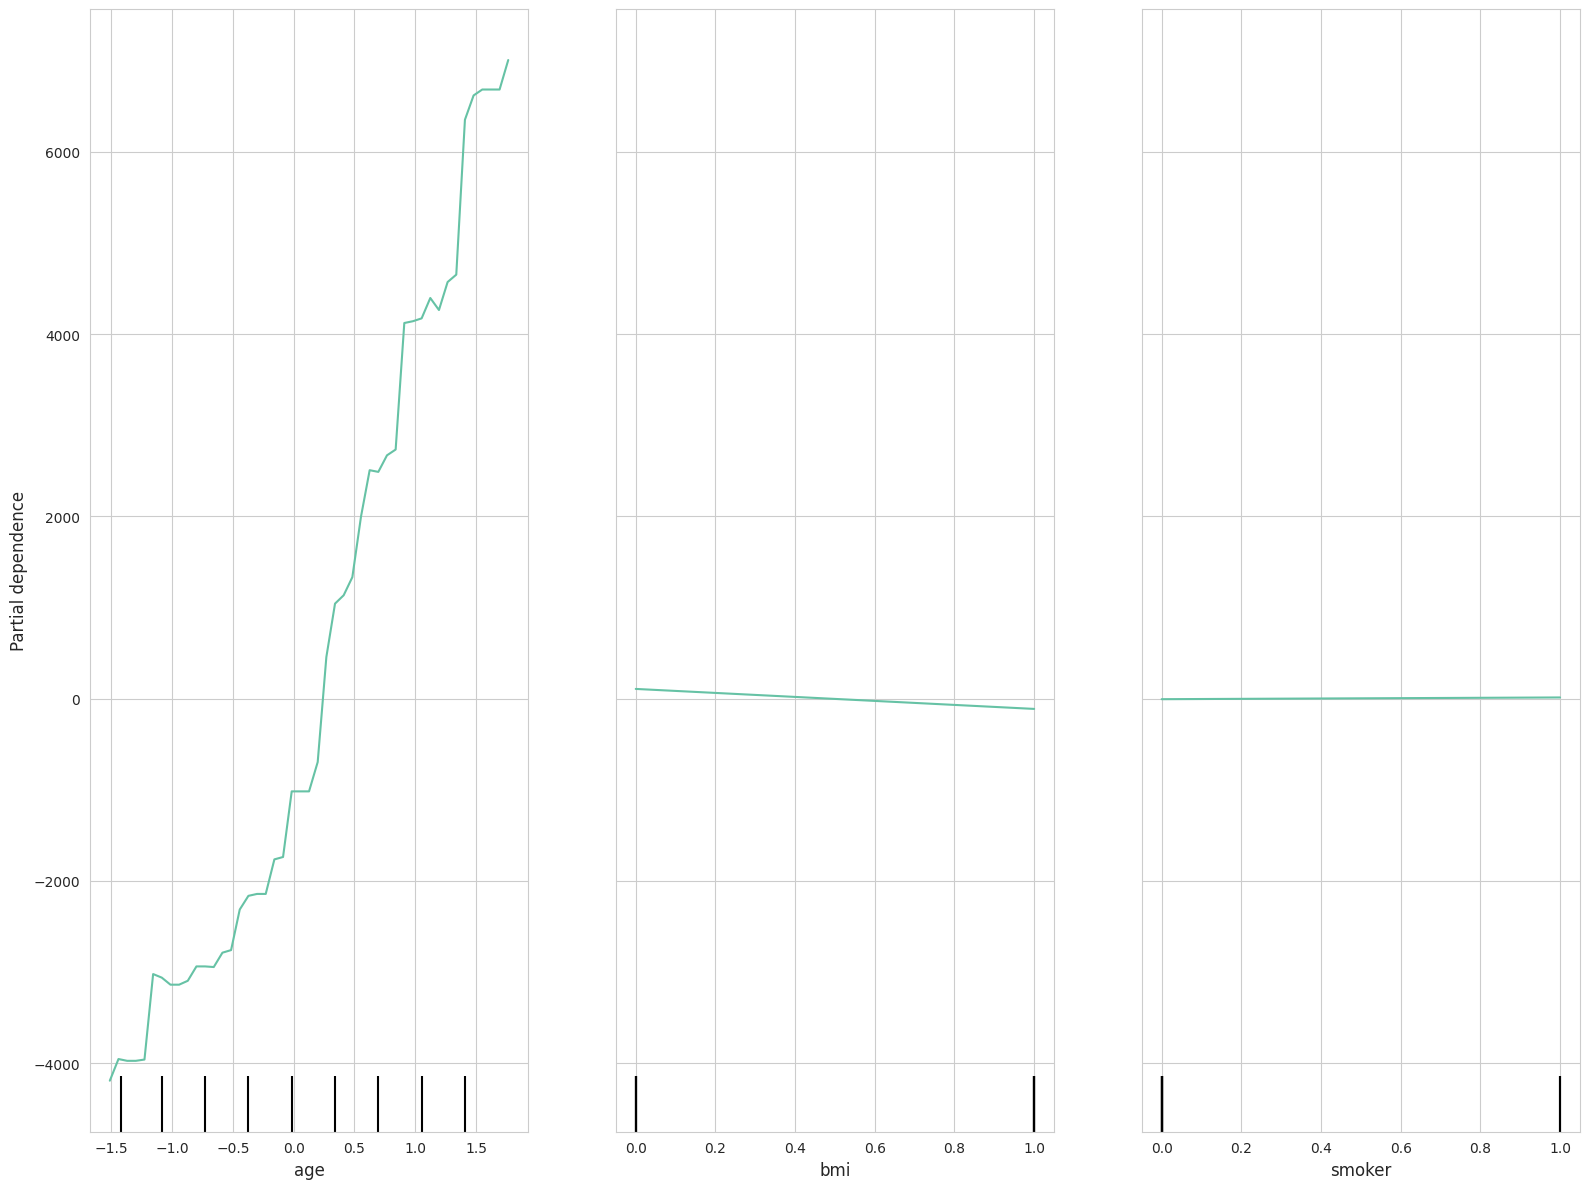

In [ ]:
# Features to plot (categorical features are automatically handled)
features_to_plot = ['age', 'bmi', 'smoker']

# Plot PDP
PartialDependenceDisplay.from_estimator(
    best_model,
    X_train,
    features=features_to_plot,
    feature_names=features,
    grid_resolution=50
)
plt.tight_layout()
plt.show()
